In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import wandb
import os

In [3]:
batch_size = 32
img_height = 180
img_width = 180
train_path='C:\\Users\\Dell\\Desktop\\Courses\\Sem_VIII\\DA6401\\DA6401-Introduction-to-Deep-Learning\\Assignment_2\\inaturalist_12K\\train'

In [6]:
!wget https://storage.googleapis.com/wandb_datasets/nature_12K.zip
!unzip nature_12K.zip
!rm nature_12K.zip

--2025-04-16 21:22:27--  https://storage.googleapis.com/wandb_datasets/nature_12K.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.206.207, 173.194.64.207, 173.194.194.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.206.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3816687935 (3.6G) [application/zip]
Saving to: ‘nature_12K.zip’

nature_12K.zip      100%[===================>]   3.55G   282MB/s    in 13s     

2025-04-16 21:22:40 (288 MB/s) - ‘nature_12K.zip’ saved [3816687935/3816687935]

Archive:  nature_12K.zip
   creating: inaturalist_12K/
  inflating: inaturalist_12K/.DS_Store  
   creating: inaturalist_12K/train/
   creating: inaturalist_12K/train/Plantae/
  inflating: inaturalist_12K/train/Plantae/1dfc3916ad58af6ce9af9fc8b36ceedd.jpg  
  inflating: inaturalist_12K/train/Plantae/e49eeff2b27ae74351fdf8ffa3791307.jpg  
  inflating: inaturalist_12K/train/Plantae/519ae1c558dff337bb4084934e31a4a8.jpg 

In [8]:
# WandB initialization
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: anshul_2010 (anshul_2010-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Hyperparameters for sweep
sweep_config = {
    'method': 'bayes',
    'metric': {
      'name': 'model_accuracy',
      'goal': 'maximize'   
    },
    'parameters': {
        'epoch': {
            'values': [50]
        },
        'dropout':{
            'values': [0.1, 0.2, 0.3]
        },
        'number_of_filters': {
            'values': [32]
        },
        'filter_organisation': {
            'values': [2]
        },
        'size_filter':{
            'values': [3]
        },
        'data_augmentation': {
            'values':['Yes']
        },
        'batch_normalization': {
            'values':['Yes', 'No']
        },
        'learning_rate':{
            'values': [0.001, 0.01, 0.0001]
        },
        'optimizer_fn':{
            'values': ['adam', 'sgd', 'momentum']
        },
        'activation_fn':{
            'values': ['relu', 'tanh']
        },
        'dense':{
            'values': [128, 256, 512]
        },
        'stride':{
            'values': [2]
        }
    }
}

In [5]:
# Data Preparation with PyTorch DataLoader
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_valid = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform_train)
valid_dataset = datasets.ImageFolder(root=train_path, transform=transform_valid)

train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_subset, valid_subset = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False)

In [6]:
# Define the CNN Model in PyTorch
class CNN_Model(nn.Module):
    def __init__(self, num_filters, filter_organisation, size_filter, dropout, activation_fn, dense_units, stride, batch_normalization):
        super(CNN_Model, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, 
                               out_channels=num_filters, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(num_filters) if batch_normalization == 'Yes' else nn.Identity()
        self.conv2 = nn.Conv2d(in_channels=num_filters, 
                               out_channels=num_filters * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(num_filters * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv3 = nn.Conv2d(in_channels=num_filters * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv4 = nn.Conv2d(in_channels=num_filters * filter_organisation * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv5 = nn.Conv2d(in_channels=num_filters * filter_organisation * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=stride, padding=1)
        self.bn5 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        
        self.fc1 = nn.Linear(num_filters * filter_organisation * filter_organisation * 4, dense_units)
        self.fc2 = nn.Linear(dense_units, 10)
        
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation_fn == 'relu' else torch.tanh
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return F.log_softmax(x, dim=1)

In [9]:
def train_model(epoch, dropout, number_of_filters, filter_organisation, size_filter, data_augmentation, batch_normalization, learning_rate, optimizer_fn, activation_fn, dense, stride):
    # Model setup
    model = CNN_Model(
        num_filters=number_of_filters,
        filter_organisation=filter_organisation,
        size_filter=size_filter,
        dropout=dropout,
        activation_fn=activation_fn,
        dense_units=dense,
        stride=stride,
        batch_normalization=batch_normalization
    )
    
    # Set up optimizer
    if optimizer_fn == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_fn == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.0)
    elif optimizer_fn == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    model.train()
    for epoch in range(epoch):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epoch}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.2f}%")
        
        wandb.log({
            'accuracy': train_accuracy,
            'loss': running_loss / len(train_loader)
        })
    
    wandb.log({'model_accuracy': train_accuracy})

    return model

In [12]:
class_names = train_dataset.classes
print(class_names)

['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


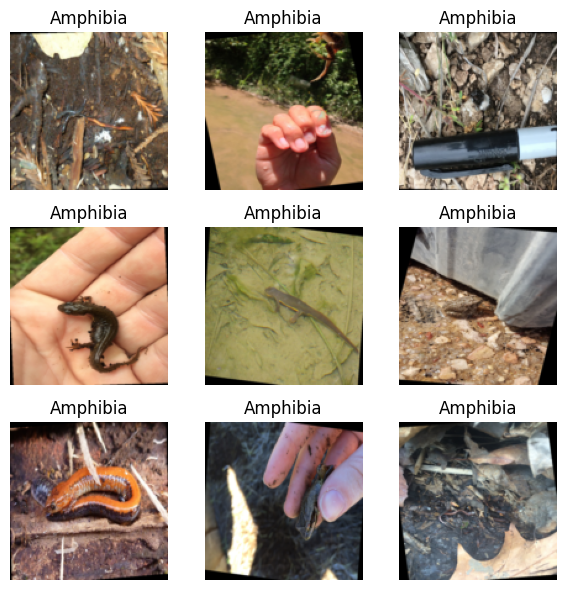

In [14]:
# Access class names
class_names = train_dataset.classes

# Plot first 9 images
plt.figure(figsize=(6, 6))
for i in range(9):
    image, label = train_dataset[i]  # get image and label from Subset
    image = image.permute(1, 2, 0)  # [C, H, W] -> [H, W, C]
    
    # Unnormalize (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    image = image * std + mean
    image = image.clamp(0, 1)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Sweep function
def train():
    config_defaults = {
        'epoch': 50,
        'dropout': 0.2,
        'number_of_filters': 32,
        'filter_organisation': 2,
        'size_filter': 3,
        'data_augmentation': 'Yes',
        'batch_normalization': 'Yes',
        'learning_rate': 0.001,
        'optimiser_fn': 'adam',
        'activation_fn': 'relu',
        'dense': 256,
        'stride': 2    
    }
    
    # Initialize a new wandb run
    wandb.init(config=config_defaults, resume='allow')
    
    # Config is a variable that holds and saves hyperparameters and inputs
    config = wandb.config
    
    train_model(
        config.epoch,
        config.dropout,
        config.number_of_filters,
        config.filter_organisation,
        config.size_filter,
        config.data_augmentation,
        config.batch_normalization,
        config.learning_rate,
        config.optimiser_fn,
        config.activation_fn,
        config.dense,
        config.stride
    )

In [16]:
sweep_id = wandb.sweep(sweep_config, project="DA6401-Assignment-2", entity="anshul_2010-indian-institute-of-technology-madras")

Create sweep with ID: owp2zicv
Sweep URL: https://wandb.ai/anshul_2010-indian-institute-of-technology-madras/DA6401-Assignment-2/sweeps/owp2zicv


In [20]:
wandb.agent(sweep_id, train,count=15)

wandb: Agent Starting Run: y4mdavl0 with config:
wandb: 	activation_fn: relu
wandb: 	batch_normalization: Yes
wandb: 	data_augmentation: Yes
wandb: 	dense: 256
wandb: 	dropout: 0.3
wandb: 	epoch: 50
wandb: 	filter_organisation: 2
wandb: 	learning_rate: 0.001
wandb: 	number_of_filters: 32
wandb: 	optimizer_fn: sgd
wandb: 	size_filter: 3
wandb: 	stride: 2
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:635: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1744838758.951985     106 service.cc:148] XLA service 0x7d4ae40030f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744838758.953173     106 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1744838758.953191     106 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1744838759.756871     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/282 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.1354 - loss: 2.8026 

...

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/step - accuracy: 0.1616 - loss: 2.4221 - val_accuracy: 0.1211 - val_loss: 2.6964
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.2180 - loss: 2.1598 - val_accuracy: 0.1852 - val_loss: 2.2369
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 51s 179ms/step - accuracy: 0.2603 - loss: 2.0652 - val_accuracy: 0.2432 - val_loss: 2.0712
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 175ms/step - accuracy: 0.2829 - loss: 2.0174 - val_accuracy: 0.3063 - val_loss: 2.0324
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 176ms/step - accuracy: 0.3022 - loss: 1.9758 - val_accuracy: 0.2152 - val_loss: 2.6086
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.3097 - loss: 1.9556 - val_accuracy: 0.2733 - val_loss: 2.0970
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.3184 - loss: 1.9251 - val_accuracy: 0.2583 - val_loss: 2.1445
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 170ms/step - accuracy: 0.3373 - loss: 1

accuracy,▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
loss,█▇▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
model_accuracy,▁
val_accuracy,▁▃▄▃▅▄▄▄▅▆▆▄▆▇▇▆▆▇▆▆▇▇█▆▇▇▇▇▇█▇██▆▇█▆▇▆▇
val_loss,▇▄▂▂▆▃▃▃▃▃▁▂▆▂▂▁▁▁▁▃▂▁▁▁▂▁▂▂▃▂▃▂▂▅▅▃▇▅█▆
accuracy,0.64633
loss,1.02658
model_accuracy,0.41742
val_accuracy,0.38038
val_loss,2.56124


wandb: Agent Starting Run: y07g2mhf with config:
wandb: 	activation_fn: relu
wandb: 	batch_normalization: Yes
wandb: 	data_augmentation: Yes
wandb: 	dense: 512
wandb: 	dropout: 0.2
wandb: 	epoch: 50
wandb: 	filter_organisation: 2
wandb: 	learning_rate: 0.0001
wandb: 	number_of_filters: 32
wandb: 	optimizer_fn: adam
wandb: 	size_filter: 3
wandb: 	stride: 1


Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - accuracy: 0.2436 - loss: 2.3193 - val_accuracy: 0.1792 - val_loss: 2.5363
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 52s 182ms/step - accuracy: 0.3203 - loss: 1.9579 - val_accuracy: 0.3213 - val_loss: 2.0152
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 51s 179ms/step - accuracy: 0.3423 - loss: 1.8810 - val_accuracy: 0.3303 - val_loss: 2.1388
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.3719 - loss: 1.8169 - val_accuracy: 0.3353 - val_loss: 2.1588
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 53s 186ms/step - accuracy: 0.3998 - loss: 1.7447 - val_accuracy: 0.3293 - val_loss: 2.1916
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 53s 188ms/step - accuracy: 0.4109 - loss: 1.6801 - val_accuracy: 0.3423 - val_loss: 2.0961
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 53s 187ms/step - accuracy: 0.4412 - loss: 1.6224 - val_accuracy: 0.3674 - val_loss: 1.9791
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - accuracy: 0.4631 - loss: 1

accuracy,▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██████████
loss,█▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
model_accuracy,▁
val_accuracy,▁▅▅▅▅▆▅▆▆▆▇▇▇▇▇▇▇█▇▇▇▇▇▇▇▇▇▆▆▇▇▆█▆█▇▆▇██
val_loss,▇▂▃▄▄▂▃▁▃▂▁▁▂▃▂▃▂▂▄▂▆▄▃▃▃▄▃▇▇▅▆▅▆▄█▇█▇▆▆
accuracy,0.90222
loss,0.31119
model_accuracy,0.43844
val_accuracy,0.42342
val_loss,2.37709
